In [1]:
# from setting import parse_opts 
# from datasets.brains18 import BrainS18Dataset
# from model import generate_model
import torch

from torch.utils.data import DataLoader
import torch.nn.functional as F
from scipy import ndimage
import nibabel as nib
import sys
import os
# from utils.file_process import load_lines



import numpy as np 
import pandas as pd
from torchsummaryX import summary
import nibabel                      as nib
import nibabel.freesurfer.mghformat as mgh
import matplotlib.pyplot as plt
from datetime import datetime
import sklearn.metrics

import glob
import re

import gc
from tqdm import tqdm


In [2]:
gc.collect()
torch.cuda.empty_cache()

In [3]:
!nvidia-smi

Thu May 16 00:28:50 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 545.23.08              Driver Version: 545.23.08    CUDA Version: 12.3     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla V100-SXM2-32GB           On  | 00000000:3B:00.0 Off |                    0 |
| N/A   28C    P0              40W / 300W |      0MiB / 32768MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [4]:
import os
os.getcwd()

'/ocean/projects/cis230054p/ytam/Model'

In [5]:
# Optional: set project root manually
# os.chdir('<project_root>')
os.getcwd()

'/ocean/projects/cis230054p/ytam'

In [6]:
ADNI_actual_used_seg_df = pd.read_csv(r'ADNI_actual_used_seg_2.csv')

In [7]:
from MedicalNet.models import resnet_stack_fusion_concat

In [8]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Device: ", device)

Device:  cuda


In [9]:
W, H, D = 256, 256, 256

In [10]:
# getting model

model = resnet_stack_fusion_concat.resnet10(sample_input_W=W,
                sample_input_H=H,
                sample_input_D=D,
                shortcut_type='B',
                no_cuda = False,
                num_classes=2).to(device)

# https://stackoverflow.com/questions/54058256/runtimeerror-errors-in-loading-state-dict-for-resnet

/ocean/projects/cis230054p/ytam/MedicalNet/models/resnet_stack_fusion_concat.py:164: UserWarning: nn.init.kaiming_normal is now deprecated in favor of nn.init.kaiming_normal_.
  m.weight = nn.init.kaiming_normal(m.weight, mode='fan_out')


In [11]:
# first dim:  image
# second dim: segmentation

# Set seg_path

In [12]:
seg_path = r"./fastsurfer_stacked/fastsurfer_seg/{}_{}/mri/aparc.DKTatlas+aseg.deep.mgz"
# img_path = r"fastsurfer_seg_masked\masked_orig_nu_{}_{}.npy"
stacked_path = r"./fastsurfer_stacked/stacked_orig_seg_{}_{}.npy"

In [13]:
seg_path

'/ocean/projects/cis230054p/ytam/fastsurfer_stacked/fastsurfer_seg/{}_{}/mri/aparc.DKTatlas+aseg.deep.mgz'

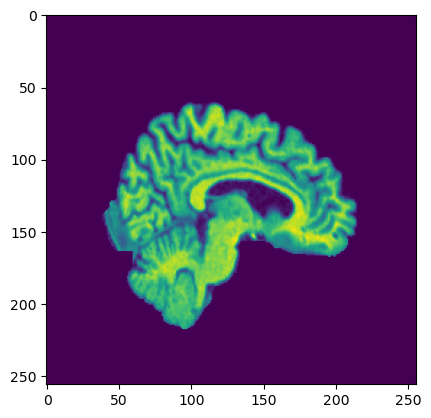

In [14]:
plt.imshow(np.load(r'./fastsurfer_stacked/stacked_orig_seg_sub-ADNI941S1203_ses-M00.npy')[0,120])

In [15]:
read_img = np.load(r'./fastsurfer_stacked/stacked_orig_seg_sub-ADNI941S1203_ses-M00.npy')[0]

In [16]:
read_img.shape

(256, 256, 256)

# Dataset

In [17]:
import os
import pandas as pd
from torch.utils.data import Dataset
import torch

class ADNI_stacked(Dataset):
    def __init__(self, csv_file, stacked_path, split = 'train', transform=None, target_transform=None):
        df = pd.read_csv(csv_file)
        
        if split == 'train':
            self.img_labels = df[df.split == 'train'] 
        elif split == 'val':
            self.img_labels = df[df.split == 'val'] 
        elif split == 'test':
            self.img_labels = df[df.split == 'test'] 
        self.stacked_path = stacked_path
        self.transform = transform
        self.target_transform = target_transform


    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        subject_id = self.img_labels.iloc[idx, 0]
        session_id = self.img_labels.iloc[idx, 1]
        final_path = self.stacked_path.format(subject_id, session_id)
        
        # np load
        stacked = np.load(final_path)

        label = self.img_labels.iloc[idx, 4]
        if self.transform:
            stacked = self.transform(stacked)
        if self.target_transform:
            label = self.target_transform(label)
        return stacked, label

In [18]:
# use seg_2 because of one (1) missing aseg_stat, reduce N to 2208
train_data = ADNI_stacked(r'ADNI_actual_used_seg_2.csv', stacked_path, split = 'train')
val_data = ADNI_stacked(r'ADNI_actual_used_seg_2.csv', stacked_path, split = 'val')
test_data = ADNI_stacked(r'ADNI_actual_used_seg_2.csv', stacked_path, split = 'test')

# DataLoader

In [19]:
from torch.utils.data import DataLoader
train_batch_size = 4 # smaller_batch
batch_size = 4

train_dataloader = DataLoader(train_data, batch_size=train_batch_size , shuffle=True, drop_last=True)
val_dataloader = DataLoader(val_data, batch_size=batch_size , shuffle=False)
test_dataloader = DataLoader(test_data, batch_size=batch_size , shuffle=False)

Feature batch shape: torch.Size([2, 256, 256, 256])
Labels batch shape: 0


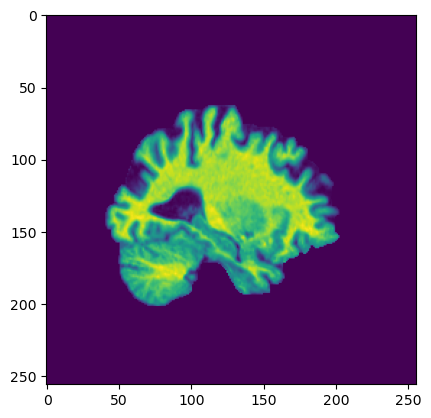

Label: 0


In [20]:
# Display image and label.
train_features, train_labels = next(iter(train_dataloader))
print(f"Feature batch shape: {train_features[0].size()}")
print(f"Labels batch shape: {train_labels[0]}")
img = train_features[0][0][100].squeeze()
label = train_labels[0]
plt.imshow(img)
plt.show()
print(f"Label: {label}")

In [21]:
loss_function = torch.nn.CrossEntropyLoss()
# loss_function = torch.nn.BCEWithLogitsLoss()  

optimizer = torch.optim.Adam(model.parameters(), 1e-4)

In [22]:
# PATH = r'ResNet3d_multimodal_imgfrompretrain_segfromscratch_20231222_124640_f10.8558352402745995_epoch70.pth'
PATH = r'ResNet3d_multimodal_Dec30-100-0.03-0.81-0.00-1.00.pt'

checkpoint = torch.load(PATH)
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
epoch_from_checkpoint = checkpoint['epoch']
loss = checkpoint['loss']


In [23]:
try:
    if PATH != None:
        epoch_start = epoch_from_checkpoint
except:
    epoch_start = 0


In [24]:
epoch_start

100

In [25]:
from torchsummaryX import summary
for i, data in enumerate(train_dataloader):
    x, y = data
    x = x.float().to(device)
    x = x.reshape(train_batch_size, -1, 256, 256, 256)
    print(x.shape)
    
    input1 = x[:,0,:,:,:].unsqueeze(1)
    input2 = x[:,1,:,:,:].unsqueeze(1)
    print(input1.shape, input2.shape)
    
    print(y.shape)

    summary(model, [input1, input2])

    out = model([input1, input2])
    print()

    print(out.shape)
    print(out)
    break


torch.Size([4, 2, 256, 256, 256])
torch.Size([4, 1, 256, 256, 256]) torch.Size([4, 1, 256, 256, 256])
torch.Size([4])


/jet/home/ytam/.local/lib/python3.9/site-packages/torchsummaryX/torchsummaryX.py:101: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  df_sum = df.sum()


                                             Kernel Shape  \
Layer                                                       
0_conv1                                  [1, 64, 7, 7, 7]   
1_bn1                                                [64]   
2_relu1                                                 -   
3_maxpool1                                              -   
4_conv2                                  [1, 64, 7, 7, 7]   
5_bn2                                                [64]   
6_relu2                                                 -   
7_maxpool2                                              -   
8_layer1.0.Conv3d_conv1                 [64, 64, 3, 3, 3]   
9_layer1.0.BatchNorm3d_bn1                           [64]   
10_layer1.0.ReLU_relu                                   -   
11_layer1.0.Conv3d_conv2                [64, 64, 3, 3, 3]   
12_layer1.0.BatchNorm3d_bn2                          [64]   
13_layer1.0.ReLU_relu                                   -   
14_layer2.0.Conv3d_conv1

In [26]:
gc.collect()
torch.cuda.empty_cache()

In [27]:
from torch.utils.tensorboard import SummaryWriter

In [28]:
# # %%
# val_interval = 2
# best_metric = -1
# best_metric_epoch = -1
# epoch_loss_values = []
# metric_values = []
# writer = SummaryWriter()
# max_epochs = 200
# timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# train_preds_lst = []
# train_labels_lst = []
# val_preds_lst = []
# val_labels_lst = []

# for epoch in range(epoch_start, max_epochs):
#     print(epoch)
#     model.train()
#     epoch_loss = 0
#     step = 0

#     for batch_data in tqdm(train_dataloader):
#         step += 1
#         labels = batch_data[1].to(device)
#         # inputs shape batchsize
        
#         inputs = batch_data[0].view(-1, 2, 256, 256, 256).float() # input channel = 2
        
#         input1 = inputs[:,0,:,:,:].unsqueeze(1).requires_grad_()
#         input2 = inputs[:,1,:,:,:].unsqueeze(1).requires_grad_()
        
        
#         optimizer.zero_grad()
#         outputs = model([input1.to(device), input2.to(device)])
#         loss = loss_function(outputs, labels)
#         loss.backward()

#         optimizer.step()
#         current_loss = loss.item()
#         epoch_loss += current_loss
#         epoch_len = len(train_data) // train_dataloader.batch_size
#         # print(f"{step}/{epoch_len}, train_loss: {current_loss:.4f}")
#         writer.add_scalar("train_loss", current_loss, epoch_len * epoch + step)
#         with torch.no_grad():
#             train_preds = torch.argmax(torch.nn.functional.softmax(outputs.detach()), dim=1)

#             train_preds_lst.extend(train_preds.detach().cpu().numpy())
#             train_labels_lst.extend(labels.detach().cpu().numpy())

#             # train_f1 = sklearn.metrics.f1_score(labels.detach().cpu().numpy() , train_preds.detach().cpu().numpy(), pos_label = 0)

#     epoch_loss /= step
#     epoch_loss_values.append(epoch_loss)
    
#     train_f1 = sklearn.metrics.f1_score(train_labels_lst, train_preds_lst)
#     print(f"epoch {epoch + 1} average loss: {epoch_loss:.4f}")
#     print("epoch {} train_f1: {}".format(epoch + 1, train_f1))
    
#         # empty cache
#     torch.cuda.empty_cache()
#     gc.collect()

#     # eval
#     model.eval()

#     for val_data in tqdm(val_dataloader):
#         val_inputs, val_labels = val_data[0].to(device), val_data[1].to(device)

#         # inputs shape batchsize
#         val_inputs = val_inputs.view(-1, 2, 256, 256, 256) # input channel = 2
#         with torch.no_grad():
#             val_outputs = model(val_inputs.float())
#             val_preds = torch.argmax(torch.nn.functional.softmax(val_outputs.detach()), dim=1)
#             val_preds_lst.extend(val_preds.detach().cpu().numpy())
#             val_labels_lst.extend(val_labels.detach().cpu().numpy())

            
#     val_f1 = sklearn.metrics.f1_score(val_labels_lst, val_preds_lst)
#     metric = val_f1.copy()
#     metric_values.append(metric)
#     print("epoch {} val_f1: {}".format(epoch + 1, val_f1))

#     if metric > best_metric:
#         best_metric = metric
#         best_metric_epoch = epoch + 1
    

#     print(f"Current epoch: {epoch+1} current accuracy: {metric:.4f} ")
#     print(f"Best f1: {best_metric:.4f} at epoch {best_metric_epoch}")
#     writer.add_scalar("val_f1", metric, epoch + 1)
    
#     ######################################################## save checkpoint ######################################################   
#     torch.save({
#         'epoch': epoch,
#         'model_state_dict': model.state_dict(),
#         'optimizer_state_dict': optimizer.state_dict(),
#         'loss': current_loss,
#         },  "ResNet3d_multimodal_imgfrompretrain_segfromscratch_{}_f1{}_epoch{}.pth".format(timestamp, metric, epoch+1))
    
#     print("saved model")

# print(f"Training completed, best_metric: {best_metric:.4f} at epoch: {best_metric_epoch}")
# writer.close()


In [29]:
# test
test_outputs_lst = []
test_preds_lst = []
test_labels_lst = []


# eval
model.eval()

num_correct = 0.0
metric_count = 0
for test_data in tqdm(test_dataloader):
    
    test_inputs = test_data[0].view(-1, 2, 256, 256, 256).float() # input channel = 2
    test_labels = test_data[1].to(device)

    with torch.no_grad():
        test_input1 = test_inputs[:,0,:,:,:].unsqueeze(1).requires_grad_()
        test_input2 = test_inputs[:,1,:,:,:].unsqueeze(1).requires_grad_()
        test_outputs = model([test_input1.to(device), test_input2.to(device)])
        test_preds = torch.argmax(torch.nn.functional.softmax(test_outputs.detach()), dim=1)
        test_outputs_lst.extend(test_outputs.detach().cpu().numpy())
        test_preds_lst.extend(test_preds.detach().cpu().numpy())
        test_labels_lst.extend(test_labels.detach().cpu().numpy())

# metric = num_correct / metric_count
# metric_values.append(metric)

  0%|          | 0/98 [00:00<?, ?it/s]/var/tmp/ipykernel_40753/3716869371.py:21: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  test_preds = torch.argmax(torch.nn.functional.softmax(test_outputs.detach()), dim=1)
100%|██████████| 98/98 [02:06<00:00,  1.29s/it]


In [30]:
# sklearn 
import sklearn.metrics

sklearn.metrics.f1_score(test_labels_lst, test_preds_lst, average = 'micro')

0.8149100257069409

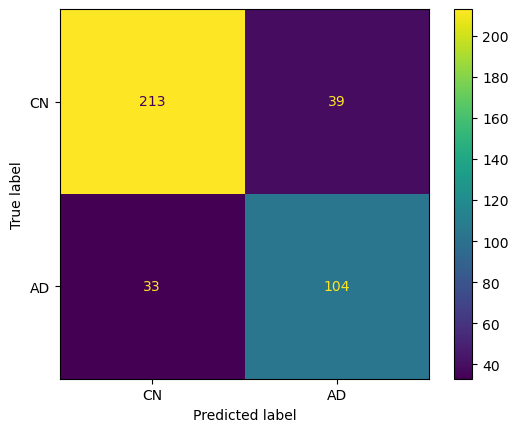

In [31]:
cm = sklearn.metrics.confusion_matrix(test_labels_lst, test_preds_lst)
sklearn.metrics.ConfusionMatrixDisplay(cm, display_labels= ['CN', 'AD']).plot()

In [32]:
# print(f'Epoch: {epoch+1}')
print(sklearn.metrics.classification_report(test_labels_lst, test_preds_lst))

              precision    recall  f1-score   support

           0       0.87      0.85      0.86       252
           1       0.73      0.76      0.74       137

    accuracy                           0.81       389
   macro avg       0.80      0.80      0.80       389
weighted avg       0.82      0.81      0.82       389



In [33]:
test_prob_preds_lst = torch.nn.functional.softmax(torch.Tensor(test_outputs_lst))[:,1]
sklearn.metrics.roc_auc_score(test_labels_lst, test_prob_preds_lst)

/var/tmp/ipykernel_40753/3927507185.py:1: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:261.)
  test_prob_preds_lst = torch.nn.functional.softmax(torch.Tensor(test_outputs_lst))[:,1]
/var/tmp/ipykernel_40753/3927507185.py:1: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  test_prob_preds_lst = torch.nn.functional.softmax(torch.Tensor(test_outputs_lst))[:,1]


0.8630517900590894

In [34]:
print('F1:' + str(sklearn.metrics.f1_score(test_labels_lst, test_preds_lst, average = 'micro')))
print('BA: '+ str(sklearn.metrics.balanced_accuracy_score(test_labels_lst, test_preds_lst)))
print('AUROC: '+ str(sklearn.metrics.roc_auc_score(test_labels_lst, test_prob_preds_lst)))
print('AUPRC: '+ str(sklearn.metrics.average_precision_score(test_labels_lst, test_prob_preds_lst, pos_label=1)))

F1:0.8149100257069409
BA: 0.8021810914146681
AUROC: 0.8630517900590894
AUPRC: 0.8451630126707175


In [35]:
pd.Series(test_preds_lst, name = 'bimodal_midfusion_pred')

0      1
1      1
2      1
3      0
4      0
      ..
384    0
385    1
386    0
387    0
388    0
Name: bimodal_midfusion_pred, Length: 389, dtype: int64

In [36]:
pd.Series(test_prob_preds_lst, name = 'bimodal_midfusion_prob_pred')

0      9.999317e-01
1      9.999975e-01
2      9.999988e-01
3      3.883148e-05
4      2.535153e-07
           ...     
384    7.842945e-02
385    9.531640e-01
386    1.884873e-03
387    1.065909e-02
388    1.265519e-04
Name: bimodal_midfusion_prob_pred, Length: 389, dtype: float32

In [37]:
test_result_df = pd.concat([ADNI_actual_used_seg_df[ADNI_actual_used_seg_df.split == 'test'].reset_index(), pd.Series(test_preds_lst, name = 'bimodal_midfusion_pred'),pd.Series(test_prob_preds_lst, name = 'bimodal_midfusion_prob_pred')],  axis = 1)

In [38]:
test_result_df

,index,participant_id,session_id,age,sex,diagnosis,split,bimodal_midfusion_pred,bimodal_midfusion_prob_pred
0,95,sub-ADNI126S0891,ses-M06,79.3,Female,1,test,1,9.999317e-01
1,96,sub-ADNI126S0891,ses-M12,79.3,Female,1,test,1,9.999975e-01
2,97,sub-ADNI126S0891,ses-M24,79.3,Female,1,test,1,9.999988e-01
3,108,sub-ADNI114S0416,ses-M00,75.6,Female,0,test,0,3.883148e-05
4,109,sub-ADNI114S0416,ses-M06,75.6,Female,0,test,0,2.535153e-07
...,...,...,...,...,...,...,...,...,...
384,2186,sub-ADNI023S0058,ses-M24,70.1,Male,0,test,0,7.842945e-02
385,2187,sub-ADNI023S0058,ses-M48,70.1,Male,0,test,1,9.531640e-01
386,2188,sub-ADNI023S0058,ses-M60,70.1,Male,0,test,0,1.884873e-03
387,2189,sub-ADNI023S0058,ses-M72,70.1,Male,0,test,0,1.065909e-02


In [39]:
test_result_df.to_csv('test_result_df_bimodal_midfusion_pred_epoch_100.csv')